1. библиотеки

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

2. Загрузка данных и первичная проверка

In [2]:
fruit_df = pd.read_csv("fruit_classification_dataset.csv")
fruit_df.head()

,size (cm),shape,weight (g),avg_price (₹),color,taste,fruit_name
0,25.4,round,3089.2,137.1,green,sweet,watermelon
1,24.6,round,3283.9,163.8,green,sweet,watermelon
2,7.8,round,319.0,91.3,green,sweet,custard apple
3,20.0,oval,1607.0,85.7,orange,sweet,papaya
4,10.2,long,131.5,37.8,yellow,sweet,banana


3. Информация о данных

In [3]:
fruit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   size (cm)      10000 non-null  float64
 1   shape          10000 non-null  object 
 2   weight (g)     10000 non-null  float64
 3   avg_price (₹)  10000 non-null  float64
 4   color          10000 non-null  object 
 5   taste          10000 non-null  object 
 6   fruit_name     10000 non-null  object 
dtypes: float64(3), object(4)
memory usage: 547.0+ KB


In [4]:
fruit_df.columns

Index(['size (cm)', 'shape', 'weight (g)', 'avg_price (₹)', 'color', 'taste',
       'fruit_name'],
      dtype='object')

In [5]:
fruit_df.shape 

(10000, 7)

4. Проверка типов данных

In [6]:
fruit_df.dtypes

cat_cols = fruit_df.select_dtypes(include=['object']).columns # текст(он же категории)
num_cols = fruit_df.select_dtypes(exclude=['object']).columns # всё остальоне

print("Категориальные:", cat_cols)
print("Числовые:", num_cols)

Категориальные: Index(['shape', 'color', 'taste', 'fruit_name'], dtype='object')
Числовые: Index(['size (cm)', 'weight (g)', 'avg_price (₹)'], dtype='object')


5. Проверка пропусков

In [7]:
fruit_df.isnull().sum()

size (cm)        0
shape            0
weight (g)       0
avg_price (₹)    0
color            0
taste            0
fruit_name       0
dtype: int64

6. Проверка дубликатов

In [8]:
fruit_df.duplicated().sum()

np.int64(246)

In [9]:
fruit_df = fruit_df.drop_duplicates()

In [10]:
fruit_df.duplicated().sum()

np.int64(0)

7. Статистическое описание

In [11]:
# Для числовых:
fruit_df.describe()

,size (cm),weight (g),avg_price (₹)
count,9754.000000,9754.000000,9754.000000
mean,8.611195,466.779209,78.423621
std,6.372831,737.286782,38.324394
min,0.900000,4.500000,9.000000
25%,4.000000,47.600000,49.000000
50%,7.300000,177.200000,76.300000
75%,10.200000,375.650000,101.700000
max,27.500000,3299.800000,165.000000


In [12]:
# Для категориальных:
fruit_df.describe(include=['object'])

,shape,color,taste,fruit_name
count,9754,9754,9754,9754
unique,3,8,3,20
top,round,green,sweet,pear
freq,4796,2029,7261,534


8. Анализ категориальных признаков (Barplots)

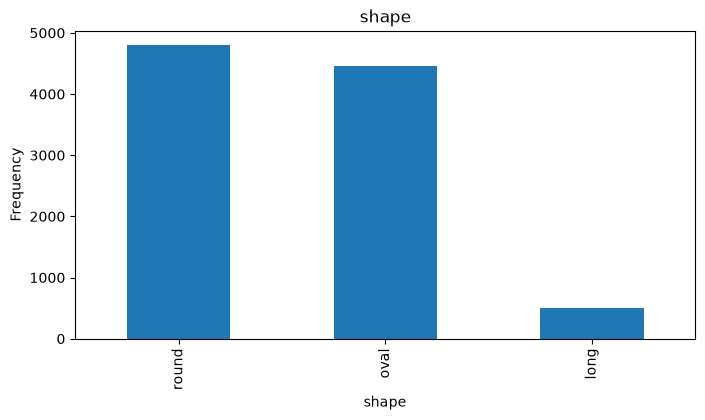

shape
round    4796
oval     4456
long      502
Name: count, dtype: int64 



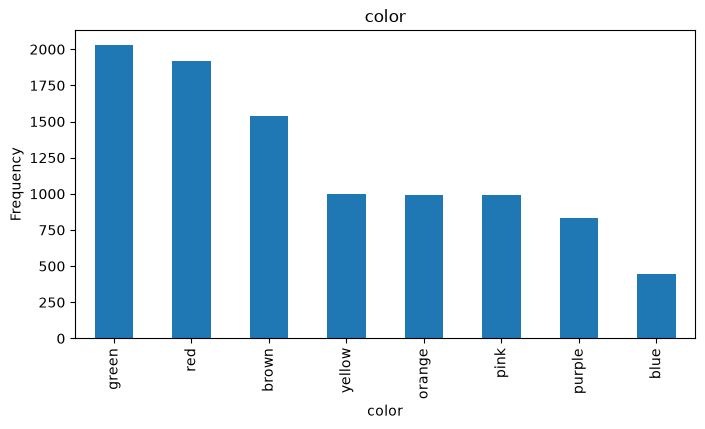

color
green     2029
red       1920
brown     1541
yellow    1002
orange     993
pink       991
purple     835
blue       443
Name: count, dtype: int64 



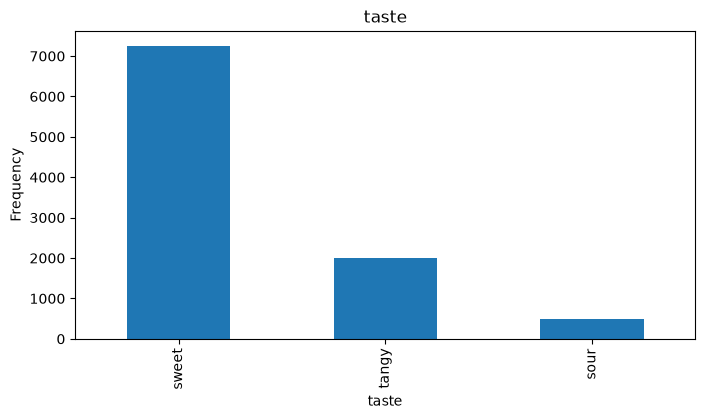

taste
sweet    7261
tangy    2012
sour      481
Name: count, dtype: int64 



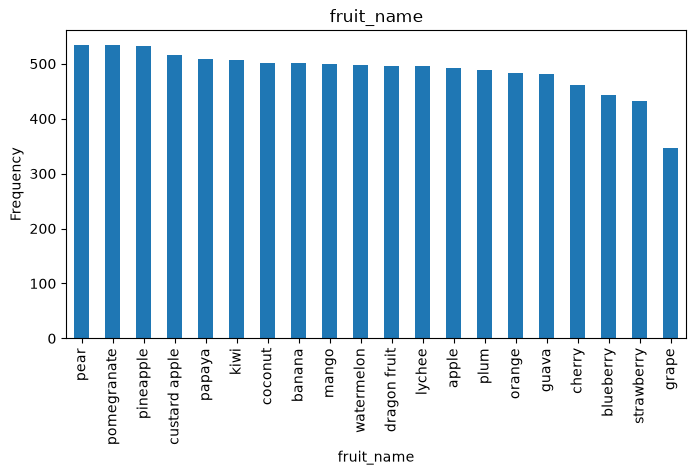

fruit_name
pear             534
pomegranate      534
pineapple        533
custard apple    516
papaya           509
kiwi             506
coconut          502
banana           502
mango            500
watermelon       498
dragon fruit     496
lychee           495
apple            492
plum             489
orange           484
guava            481
cherry           462
blueberry        443
strawberry       432
grape            346
Name: count, dtype: int64 



In [13]:
cat_cols = ['shape', 'color', 'taste', 'fruit_name']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    fruit_df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.ylabel("Frequency")
    plt.show()
    print(fruit_df[col].value_counts(), "\n")


9. Анализ числовых признаков

In [14]:
num_cols = ['size (cm)', 'weight (g)', 'avg_price (₹)']

fruit_df[num_cols].describe()

,size (cm),weight (g),avg_price (₹)
count,9754.000000,9754.000000,9754.000000
mean,8.611195,466.779209,78.423621
std,6.372831,737.286782,38.324394
min,0.900000,4.500000,9.000000
25%,4.000000,47.600000,49.000000
50%,7.300000,177.200000,76.300000
75%,10.200000,375.650000,101.700000
max,27.500000,3299.800000,165.000000


10. Гистограммы распределений

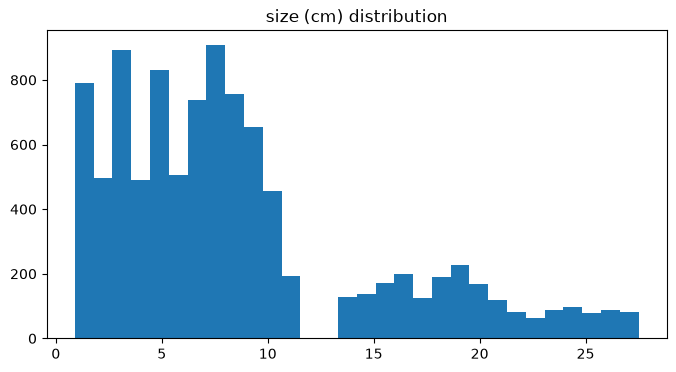

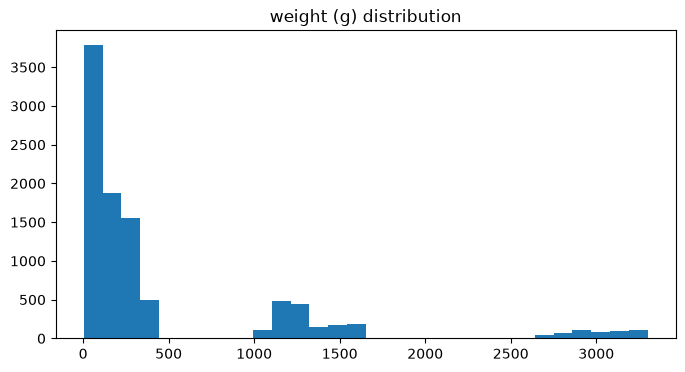

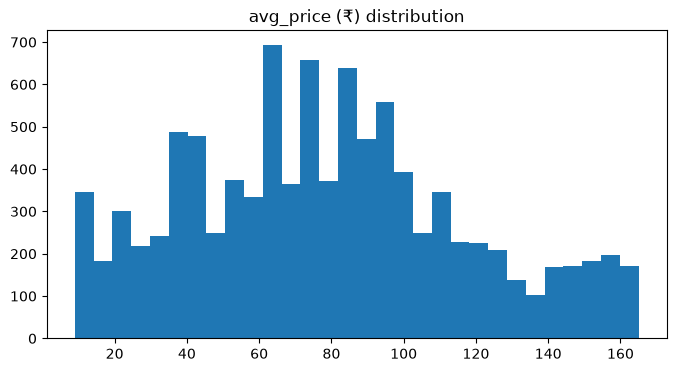

In [15]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    plt.hist(fruit_df[col], bins=30)
    plt.title(f"{col} distribution")
    plt.show()

11. Boxplot — анализ выбросов

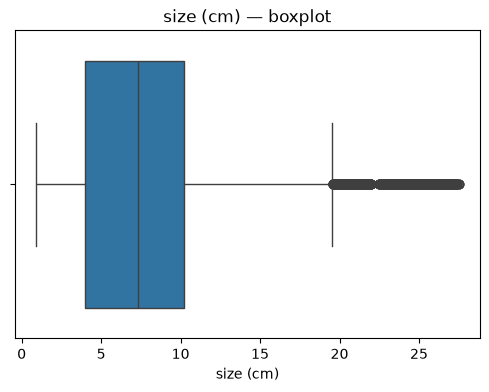

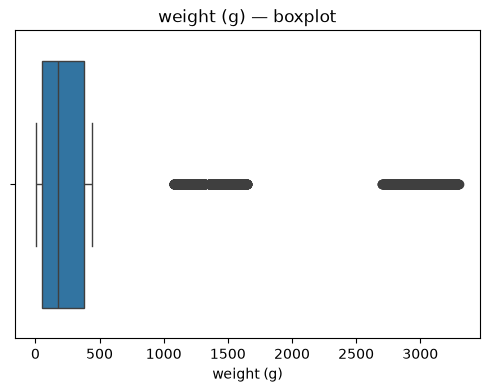

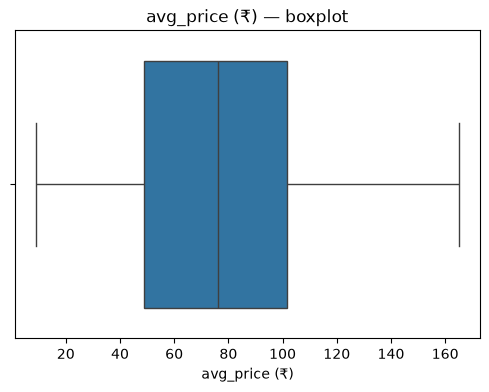

In [16]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=fruit_df[col])
    plt.title(f"{col} — boxplot")
    plt.show()

12. Pairplot (общий взгляд на зависимости)

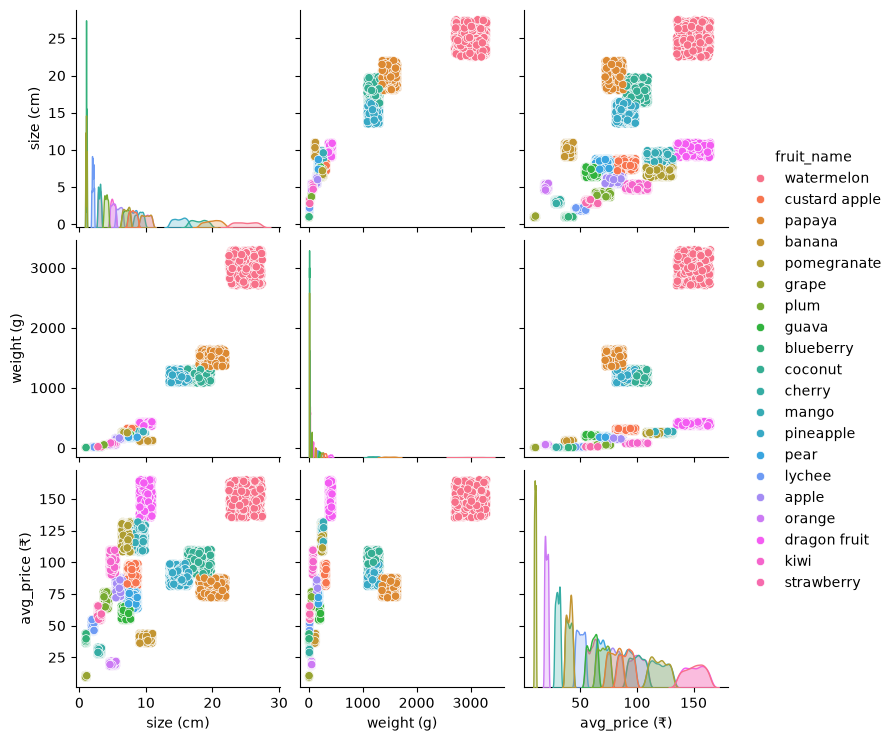

In [17]:
sns.pairplot(fruit_df, hue='fruit_name')
plt.show()

13. Корреляционный анализ

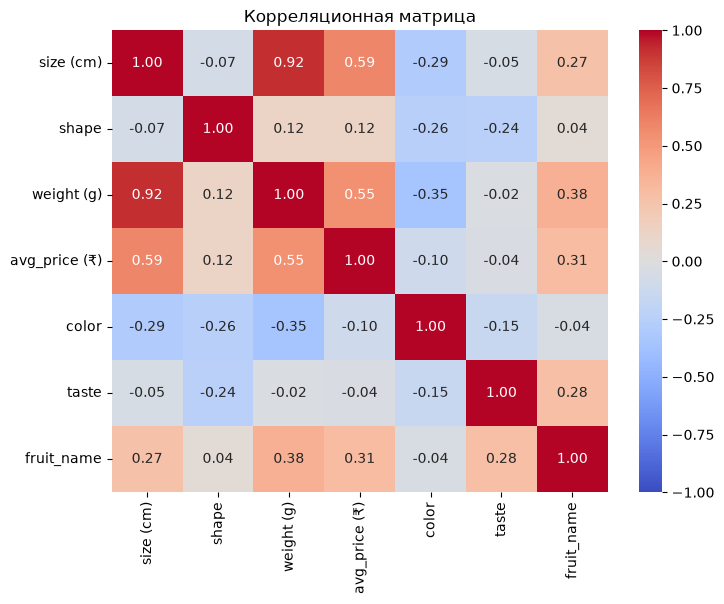

In [18]:
df_encoded = fruit_df.copy() # матрица корреляции не прнимает категории, только числа
df_encoded = df_encoded.apply(lambda x: x.astype("category").cat.codes if x.dtype == "object" else x) # числа для уникальных значений

plt.figure(figsize=(8,6))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1)
plt.title("Корреляционная матрица")
plt.show()

14. Создание новых признаков

In [19]:
# 1) Цена за грамм
fruit_df["price_per_gram"] = fruit_df["avg_price (₹)"] / fruit_df["weight (g)"]

# 2) Плотность (масса / размер)
fruit_df["density"] = fruit_df["weight (g)"] / fruit_df["size (cm)"]

# 3) Длина названия фрукта
fruit_df["fruit_name_len"] = fruit_df["fruit_name"].apply(len)

Анализ распределения новых

In [20]:
fruit_df[["price_per_gram", "density", "fruit_name_len"]].describe()

,price_per_gram,density,fruit_name_len
count,9754.000000,9754.000000,9754.000000
mean,1.219785,33.018782,7.182182
std,1.806405,30.878473,2.772321
min,0.041869,2.757576,4.000000
25%,0.291957,10.002315,5.000000
50%,0.423371,24.676645,6.000000
75%,1.447654,40.167100,10.000000
max,9.755556,144.175439,13.000000


15. Кодирование категориальных признаков (Label Encoding)

In [21]:
fruit_ml = fruit_df.copy()

fruit_ml = fruit_ml.apply(
    lambda x: x.astype("category").cat.codes if x.dtype == "object" else x
)

fruit_ml.head()

,size (cm),shape,weight (g),avg_price (₹),color,taste,fruit_name,price_per_gram,density,fruit_name_len
0,25.4,2,3089.2,137.1,2,1,19,0.044380,121.622047,10
1,24.6,2,3283.9,163.8,2,1,19,0.049880,133.491870,10
2,7.8,2,319.0,91.3,2,1,5,0.286207,40.897436,13
3,20.0,1,1607.0,85.7,3,1,13,0.053329,80.350000,6
4,10.2,0,131.5,37.8,7,1,1,0.287452,12.892157,6


16. Финальная подготовка данных для ML

In [22]:
X = fruit_ml.drop("fruit_name", axis=1) #все кроме целевой(признаки)
y = fruit_ml["fruit_name"] # целевая(что предскажем)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

Нормализация:

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)